# Projeto - NASA Turbofan Engine Degradation Dataset

O NASA Turbofan Engine Degradation Dataset contém simulações de motores de avião que vão se degradando ao longo do tempo até falhar.
A ideia central é: Prever quanto tempo falta até a falha de um equipamento. Esse problema é semelhante ao que empresas fazem com servidores, data centers, etc.

#### Arquivos

Disponível no site: https://www.kaggle.com/datasets/bishals098/nasa-turbofan-engine-degradation-simulation?resource=download

Contém 4 arquivos principais de treino, como por exemplo: train_FD001.txt.

Cada linha representa um instante de tempo de um motor.
Colunas (não vêm com nome, mas são assim):

unit_id → ID do motor
cycle → tempo (ciclo de vida)
op_setting_1, 2, 3 → condições operacionais
sensor_1 ... sensor_21 → leituras dos sensores

- O motor vai até a falha completa.

#### Visualização

In [78]:
# =========================================================
# Carregar os dados
# =========================================================

import pandas as pd

# Nomes e Número de colunas
cols = ['unit_id', 'cycle'] + \
       [f'op_setting_{i}' for i in range(1,4)] + \
       [f'sensor_{i}' for i in range(1,22)]

# Carregar treino
df = pd.read_csv('train_FD001.txt', sep=' ', header=None)
df = df.dropna(axis=1)  # remove colunas vazias
df.columns = cols

df.head()

,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


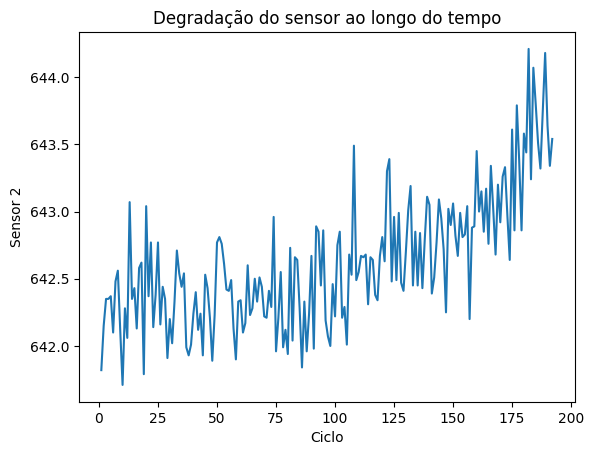

In [79]:
# =========================================================
# Visualizar um motor específico
# =========================================================

import matplotlib.pyplot as plt

motor_id = 1
motor_data = df[df['unit_id'] == motor_id]

plt.figure()
plt.plot(motor_data['cycle'], motor_data['sensor_2'])
plt.xlabel('Ciclo')
plt.ylabel('Sensor 2')
plt.title('Degradação do sensor ao longo do tempo')
plt.show()

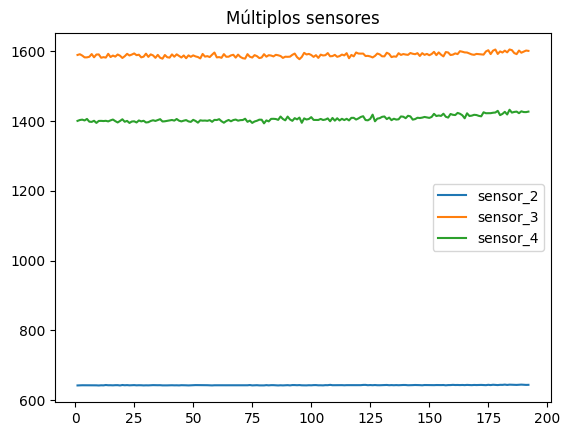

In [80]:
# =========================================================
# Visualizar vários sensores
# =========================================================

sensors = ['sensor_2', 'sensor_3', 'sensor_4']

for s in sensors:
    plt.plot(motor_data['cycle'], motor_data[s], label=s)

plt.legend()
plt.title('Múltiplos sensores')
plt.show()

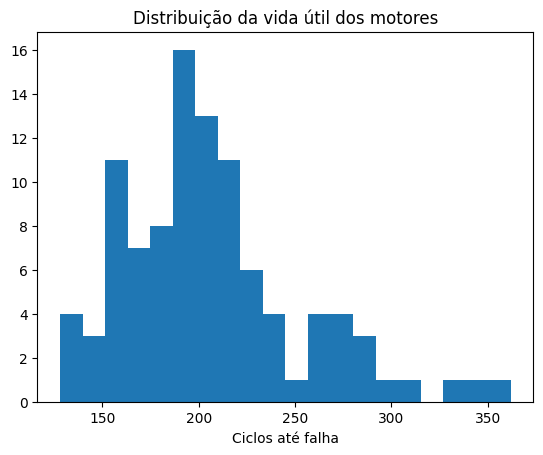

In [81]:
# =========================================================
# Ver a distribuição dos ciclos (vida dos motores)
# =========================================================

life = df.groupby('unit_id')['cycle'].max()

plt.hist(life, bins=20)
plt.title('Distribuição da vida útil dos motores')
plt.xlabel('Ciclos até falha')
plt.show()

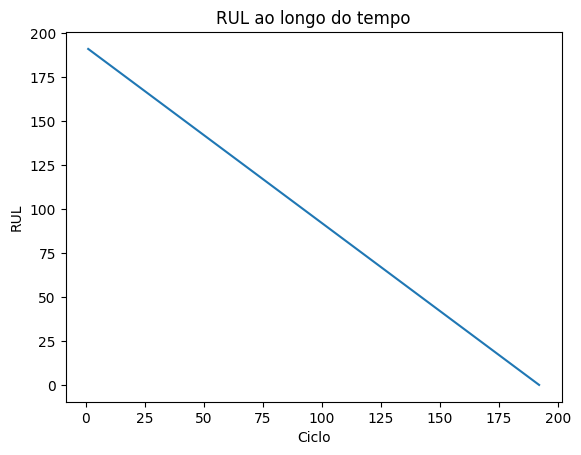

In [82]:
# =========================================================
# Criar e visualizar o RUL
# =========================================================
# RUL=(max(cycle por motor))−cycle
# Para cada motor, toma-se o último ciclo (em que ele falha) e subtrai o ciclo atual.

# =========================================================
# Criar RUL
# =========================================================
df['RUL'] = df.groupby('unit_id')['cycle'].transform('max') - df['cycle']

# =========================================================
# Plotar
# =========================================================
plt.plot(motor_data['cycle'], df[df['unit_id']==1]['RUL'])
plt.title('RUL ao longo do tempo')
plt.xlabel('Ciclo')
plt.ylabel('RUL')
plt.show()

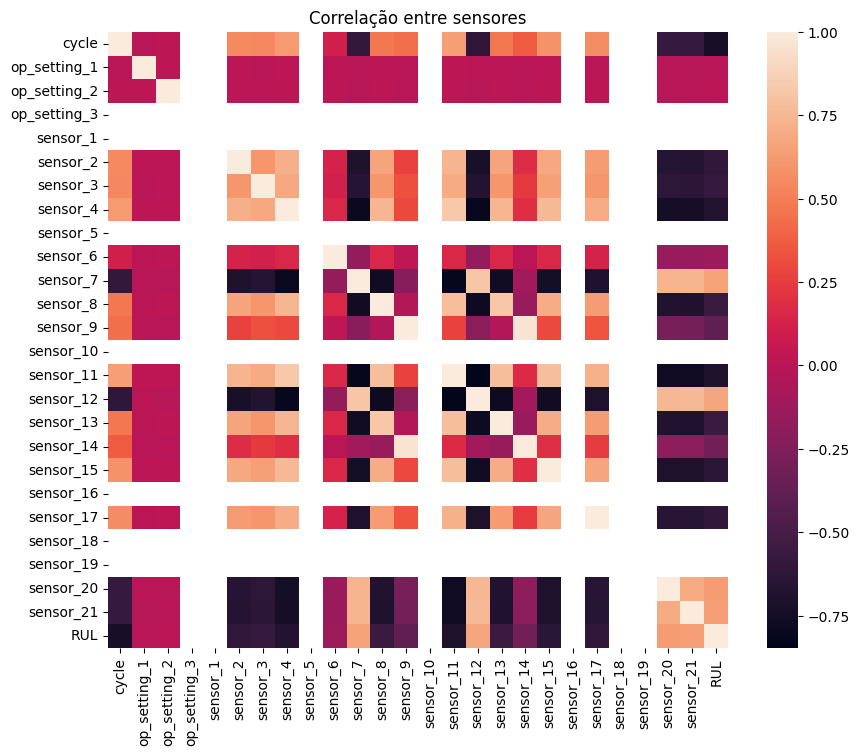

In [83]:
# =========================================================
# Heatmap de correlação
# =========================================================
# Correlação mede: “quanto duas variáveis se comportam de forma parecida”
# Valores:
# +1 → andam juntas
# 0 → não têm relação
# -1 → comportamento oposto

#%pip install seaborn
import seaborn as sns

corr = df.drop(columns=['unit_id']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr)
plt.title('Correlação entre sensores')
plt.show()

In [84]:
corr_with_rul = df.corr()['RUL'].sort_values()
print(corr_with_rul)

cycle          -0.736241
sensor_11      -0.696228
sensor_4       -0.678948
sensor_15      -0.642667
sensor_2       -0.606484
sensor_17      -0.606154
sensor_3       -0.584520
sensor_8       -0.563968
sensor_13      -0.562569
sensor_9       -0.390102
sensor_14      -0.306769
sensor_6       -0.128348
op_setting_1   -0.003198
op_setting_2   -0.001948
unit_id         0.078753
sensor_20       0.629428
sensor_21       0.635662
sensor_7        0.657223
sensor_12       0.671983
RUL             1.000000
op_setting_3         NaN
sensor_1             NaN
sensor_5             NaN
sensor_10            NaN
sensor_16            NaN
sensor_18            NaN
sensor_19            NaN
Name: RUL, dtype: float64


#### Regressão Linear

In [85]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# =========================================================
# Carregar o dataset
# =========================================================
train_df = pd.read_csv("train_FD001.txt", sep=" ", header=None)
train_df = train_df.dropna(axis=1)

# =========================================================
# Nomear as colunas
# =========================================================
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1,4)] + [f'sensor_{i}' for i in range(1,22)]
train_df.columns = cols

# =========================================================
# Criar o RUL
# =========================================================
train_df['RUL'] = train_df.groupby('unit')['cycle'].transform('max') - train_df['cycle']

# =========================================================
# RUL CLIPPING
# =========================================================
train_df['RUL'] = train_df['RUL'].clip(upper=125)

# =========================================================
# Separar o Target
# =========================================================
X = train_df.drop(columns=['RUL', 'unit', 'cycle'])
y = train_df['RUL']

###### Limpeza dos dados

In [86]:
# =========================================================
# Remover os sensores com baixa variância por motor
# =========================================================
var_per_unit = X.groupby(train_df['unit']).var()
mean_var = var_per_unit.mean()

feat_var = mean_var[mean_var > 0.01].index
X_var = X[feat_var]

print("Após variância:", X_var.shape)

# =========================================================
# Remover os sensores com baixo slope (inclinação da reta)
# =========================================================
def compute_slope(group):
    slopes = {}
    for col in X_var.columns:
        slope, _, _, _, _ = linregress(group['cycle'], group[col])
        slopes[col] = slope
    return pd.Series(slopes)

slopes = train_df[['unit', 'cycle']].join(X_var).groupby('unit').apply(compute_slope, include_groups=False)
mean_slope = slopes.abs().mean()

feat_trend = mean_slope[mean_slope > 0.001].index
X_trend = X_var[feat_trend]

print("Após tendência:", X_trend.shape)

# =========================================================
# Remover correlações entre features (por motor)
# =========================================================
corrs = []

for unit, group in train_df[['unit']].join(X_trend).groupby('unit'):
    corrs.append(group.drop(columns=['unit']).corr())

mean_corr = sum(corrs) / len(corrs)

upper = mean_corr.where(np.triu(np.ones(mean_corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

X_uncorr = X_trend.drop(columns=to_drop)

print("Após correlação entre features:", X_uncorr.shape)

# =========================================================
# Mantém os sensores com correlação com o RUL (por motor)
# =========================================================
corrs_rul = []

for unit, group in train_df[['unit', 'RUL']].join(X_uncorr).groupby('unit'):
    corr = group[X_uncorr.columns].corrwith(group['RUL'])
    corrs_rul.append(corr)

mean_corr_rul = pd.concat(corrs_rul, axis=1).mean(axis=1).abs()

feat_rul = mean_corr_rul[mean_corr_rul > 0.1].index
X_final = X_uncorr[feat_rul]

print("Features finais:", X_final.shape)
# print("Após correlação com RUL:", X_final.shape)

Após variância: (20631, 11)
Após tendência: (20631, 11)
Após correlação entre features: (20631, 11)
Features finais: (20631, 11)


Observação: As várias remoções não foram relevantes nesse dataset.

###### Regressão

In [87]:
# Não é necessário a próxima etapa pois tem-se um arquivo com testes.
# X_train, X_test, y_train, y_test = train_test_split(
#     X_final, y, test_size=0.2, random_state=42
# )

# =========================================================
# Normalização
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

# =========================================================
# Regressão linear 
# =========================================================
model = LinearRegression()
model.fit(X_scaled, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [88]:
# =========================================================
# Arquivo de teste 
# =========================================================
test_df = pd.read_csv("test_FD001.txt", sep=" ", header=None)
test_df = test_df.dropna(axis=1)
test_df.columns = cols

rul_test = pd.read_csv("RUL_FD001.txt", header=None)
rul_test.columns = ['RUL']

# =========================================================
# Selecionar o último ciclo
# =========================================================
test_last = test_df.groupby('unit').last().reset_index()

# =========================================================
# Selecionar as mesmas features
# =========================================================
X_test = test_last[X_final.columns]

# =========================================================
# Mesma normalização
# =========================================================
X_test_scaled = scaler.transform(X_test)

# =========================================================
# Predição
# =========================================================
y_pred = model.predict(X_test_scaled)

# =========================================================
# Avaliação do model
# =========================================================
rmse = np.sqrt(mean_squared_error(rul_test['RUL'], y_pred))
print("RMSE TESTE:", rmse)

RMSE TESTE: 21.91893446932296


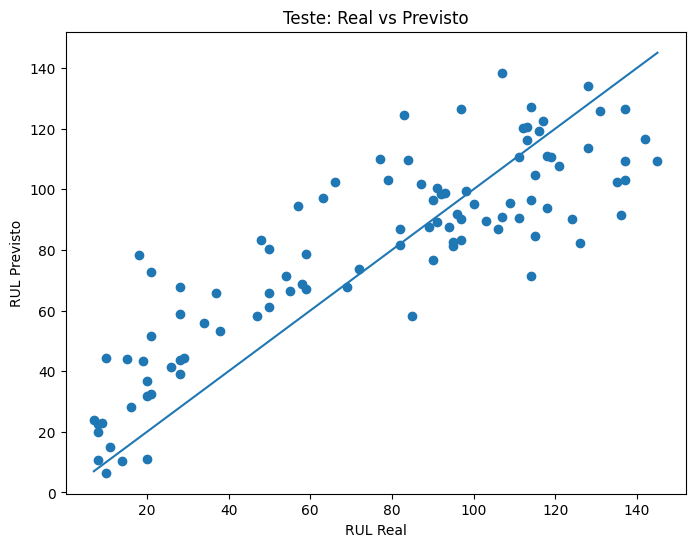

In [89]:
# =========================================================
# Gráfico do RUL - Real vs Previsto
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(rul_test['RUL'], y_pred)

# linha ideal
plt.plot(
    [rul_test['RUL'].min(), rul_test['RUL'].max()],
    [rul_test['RUL'].min(), rul_test['RUL'].max()]
)

plt.xlabel("RUL Real")
plt.ylabel("RUL Previsto")
plt.title("Teste: Real vs Previsto")

plt.show()

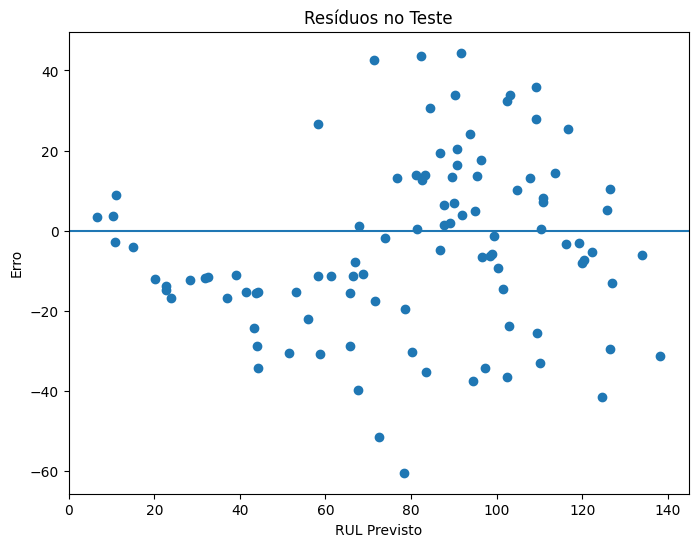

In [90]:
# =========================================================
# Gráfico de Resíduos
# =========================================================

residuals = rul_test['RUL'] - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(0)

plt.xlabel("RUL Previsto")
plt.ylabel("Erro")
plt.title("Resíduos no Teste")

plt.show()

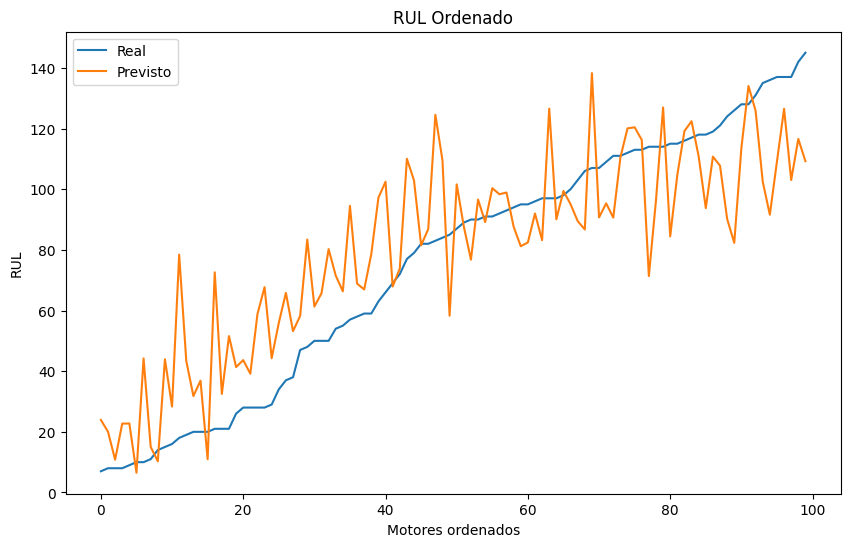

In [91]:
# =========================================================
# Curva Real vs Previsto
# =========================================================
sorted_idx = np.argsort(rul_test['RUL'])

real_sorted = rul_test['RUL'].values[sorted_idx]
pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(10,6))

plt.plot(real_sorted, label='Real')
plt.plot(pred_sorted, label='Previsto')

plt.xlabel("Motores ordenados")
plt.ylabel("RUL")

plt.title("RUL Ordenado")

plt.legend()

plt.show()

#### XGBoost

In [92]:
import pandas as pd
import numpy as np

from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_squared_error

# %pip install xgboost
from xgboost import XGBRegressor

import matplotlib.pyplot as plt

# =========================================================
# Arquivo
# =========================================================
train_df = pd.read_csv("train_FD001.txt", sep=" ", header=None)
train_df = train_df.dropna(axis=1)

cols = (
    ['unit', 'cycle']
    + [f'op_setting_{i}' for i in range(1, 4)]
    + [f'sensor_{i}' for i in range(1, 22)]
)

train_df.columns = cols

# drop_sensors = [
#     'sensor_1',
#     'sensor_5',
#     'sensor_6',
#     'sensor_10',
#     'sensor_16',
#     'sensor_18',
#     'sensor_19'
# ]

# train_df = train_df.drop(columns=drop_sensors)
# print("Shape:", train_df.shape)

# =========================================================
# Definir o RUL
# =========================================================
train_df['RUL'] = (
    train_df.groupby('unit')['cycle'].transform('max')
    - train_df['cycle']
)

# =========================================================
# RUL CLIPPING
# =========================================================
train_df['RUL'] = train_df['RUL'].clip(upper=125)

# =========================================================
# FEATURES / TARGET
# =========================================================
X_train = train_df.drop(
    columns=['RUL', 'unit', 'cycle']
)

y_train = train_df['RUL']

# =========================================================
# Remover baixa variância
# =========================================================
# XGBoost não precisa remover correlação,
# mas remover sensores quase constantes ajuda.

selector = VarianceThreshold(threshold=0.01)

X_train_var = selector.fit_transform(X_train)

selected_features = X_train.columns[
    selector.get_support()
]

X_train_var = pd.DataFrame(
    X_train_var,
    columns=selected_features
)


print("Features após etapa da variância:")
print(selected_features.tolist())

print("Shape:", X_train_var.shape)

Features após etapa da variância:
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17', 'sensor_20', 'sensor_21']
Shape: (20631, 11)


In [93]:
# =========================================================
# Modelo XGBoost
# =========================================================
model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train_var, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [94]:
# =========================================================
# Arquivo de teste
# =========================================================
test_df = pd.read_csv("test_FD001.txt", sep=" ", header=None)
test_df = test_df.dropna(axis=1)

test_df.columns = cols

# =========================================================
# Arquivo do RUL real
# =========================================================
rul_test = pd.read_csv("RUL_FD001.txt", header=None)
rul_test.columns = ['RUL']

# =========================================================
# Selecionar o último ciclo
# =========================================================
test_last = (
    test_df
    .groupby('unit')
    .last()
    .reset_index()
)

# =========================================================
# Selecionar a mesmas features
# =========================================================
X_test = test_last[selected_features]

# Predição
# =========================================================
y_pred = model.predict(X_test)

# =========================================================
# Avaliação RMSE
# =========================================================
rmse = np.sqrt(
    mean_squared_error(
        rul_test['RUL'],
        y_pred
    )
)

print("RMSE TESTE:", rmse)

RMSE TESTE: 18.81762220030569


In [99]:
# =========================================================
# Avaliação pelo NASA Score
# =========================================================

import numpy as np

def nasa_score(y_true, y_pred):
    """
    NASA Scoring Function for RUL prediction.

    Parameters
    ----------
    y_true : array-like
        True RUL values.
    y_pred : array-like
        Predicted RUL values.

    Returns
    -------
    score : float
        NASA score (lower is better).
    """

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    d = y_pred - y_true

    score = np.where(
        d < 0,
        np.exp(-d / 13) - 1,
        np.exp(d / 10) - 1
    )

    return np.sum(score)

print(nasa_score(rul_test['RUL'],y_pred))

1557.5889460436954


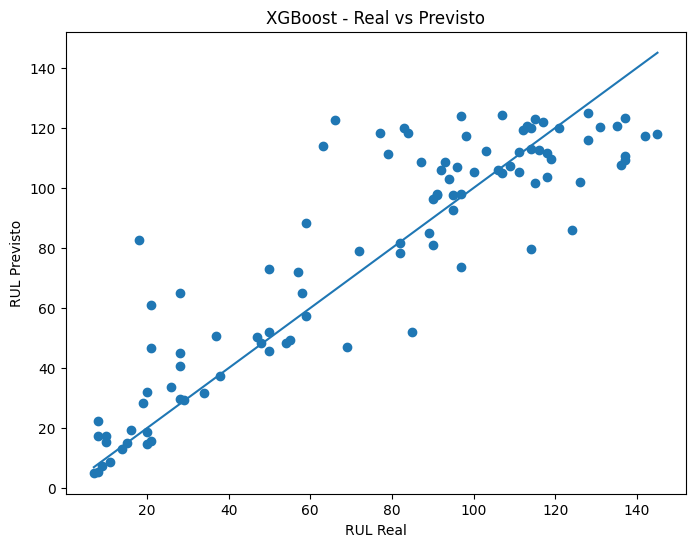

In [95]:
# =========================================================
# Gráfico Real vs Previsto
# =========================================================
plt.figure(figsize=(8,6))

plt.scatter(
    rul_test['RUL'],
    y_pred
)

# linha ideal
plt.plot(
    [
        rul_test['RUL'].min(),
        rul_test['RUL'].max()
    ],
    [
        rul_test['RUL'].min(),
        rul_test['RUL'].max()
    ]
)

plt.xlabel("RUL Real")
plt.ylabel("RUL Previsto")

plt.title("XGBoost - Real vs Previsto")

plt.show()

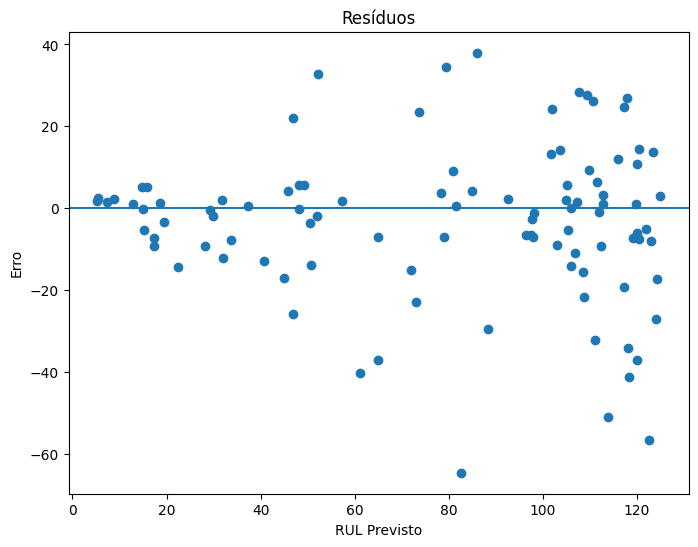

In [96]:
# =========================================================
# Résiduos
# =========================================================
residuals = rul_test['RUL'] - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(0)

plt.xlabel("RUL Previsto")
plt.ylabel("Erro")

plt.title("Resíduos")

plt.show()

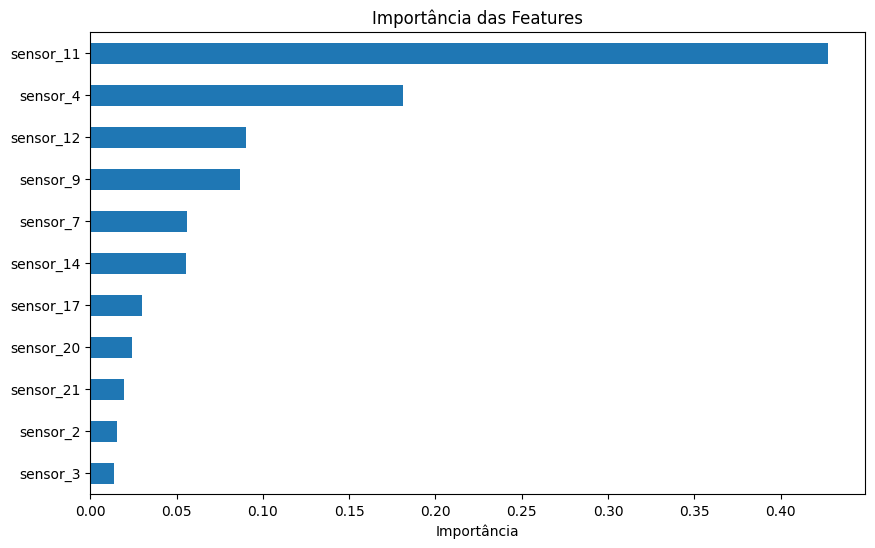

In [97]:
# =========================================================
# Importância das Features
# =========================================================
importance = pd.Series(
    model.feature_importances_,
    index=selected_features
)

importance = importance.sort_values()

plt.figure(figsize=(10,6))

importance.plot(kind='barh')

plt.xlabel("Importância")
plt.title("Importância das Features")

plt.show()

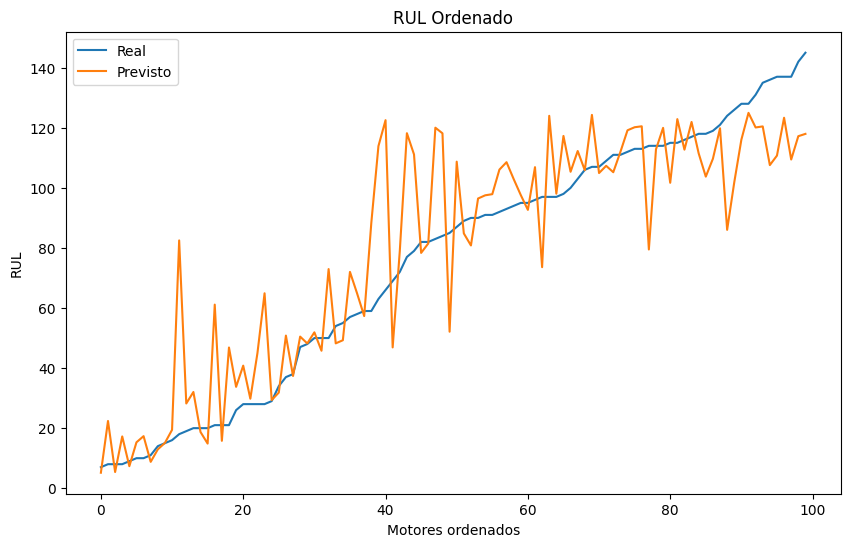

In [98]:
# =========================================================
# Curva Real vs Previsto
# =========================================================
sorted_idx = np.argsort(rul_test['RUL'])

real_sorted = rul_test['RUL'].values[sorted_idx]
pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(10,6))

plt.plot(real_sorted, label='Real')
plt.plot(pred_sorted, label='Previsto')

plt.xlabel("Motores ordenados")
plt.ylabel("RUL")

plt.title("RUL Ordenado")

plt.legend()

plt.show()

#### LSTM

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
# %pip install torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# =========================================================
# DEVICE
# =========================================================
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

# =========================================================
# LOAD TRAIN
# =========================================================
train_df = pd.read_csv(
    "train_FD001.txt",
    sep=" ",
    header=None
)

train_df = train_df.dropna(axis=1)

cols = (
    ['unit', 'cycle']
    + [f'op_setting_{i}' for i in range(1,4)]
    + [f'sensor_{i}' for i in range(1,22)]
)

train_df.columns = cols

# =========================================================
# Criar o RUL
# =========================================================
train_df['RUL'] = (
    train_df.groupby('unit')['cycle']
    .transform('max')
    - train_df['cycle']
)

# =========================================================
# RUL CLIPPING
# =========================================================
train_df['RUL'] = train_df['RUL'].clip(upper=125)

# =========================================================
# REMOVER SENSORES FRACOS
# =========================================================
drop_sensors = [
    'sensor_1',
    'sensor_5',
    'sensor_6',
    'sensor_10',
    'sensor_16',
    'sensor_18',
    'sensor_19'
]

features = [
    col for col in train_df.columns
    if col not in ['unit', 'cycle', 'RUL']
    and col not in drop_sensors
]

# =========================================================
# NORMALIZAÇÃO
# =========================================================
scaler = MinMaxScaler()

train_df[features] = scaler.fit_transform(
    train_df[features]
)

cpu


In [102]:
# =========================================================
# CRIAR SEQUÊNCIAS
# =========================================================
sequence_length = 30

def create_sequences(df, seq_length):

    X = []
    y = []

    for unit in df['unit'].unique():

        unit_df = df[df['unit'] == unit]

        data = unit_df[features].values
        rul = unit_df['RUL'].values

        for i in range(len(unit_df) - seq_length):

            X.append(
                data[i:i+seq_length]
            )

            y.append(
                rul[i+seq_length]
            )

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(
    train_df,
    sequence_length
)

print(X_train.shape)
print(y_train.shape)

# =========================================================
# DATASET
# =========================================================
class TurbofanDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

train_dataset = TurbofanDataset(
    X_train,
    y_train
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)


(17631, 30, 17)
(17631,)


In [103]:
# =========================================================
# MODELO LSTM
# =========================================================
class LSTMModel(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Sequential(

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

model = LSTMModel(
    input_size=len(features)
).to(device)

# =========================================================
# LOSS E OTIMIZADOR
# =========================================================
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# =========================================================
# TREINAMENTO
# =========================================================
epochs = 20

losses = []

for epoch in range(epochs):

    model.train()

    epoch_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)

        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch).squeeze()

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)

    losses.append(epoch_loss)

    print(
        f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}"
    )


Epoch 1/20 - Loss: 4293.8107
Epoch 2/20 - Loss: 1747.1589
Epoch 3/20 - Loss: 1747.0004
Epoch 4/20 - Loss: 1745.4042
Epoch 5/20 - Loss: 1285.2224
Epoch 6/20 - Loss: 320.9294
Epoch 7/20 - Loss: 231.3655
Epoch 8/20 - Loss: 212.1373
Epoch 9/20 - Loss: 198.1062
Epoch 10/20 - Loss: 194.0704
Epoch 11/20 - Loss: 192.5960
Epoch 12/20 - Loss: 187.0693
Epoch 13/20 - Loss: 184.1002
Epoch 14/20 - Loss: 177.2269
Epoch 15/20 - Loss: 179.3540
Epoch 16/20 - Loss: 177.3147
Epoch 17/20 - Loss: 177.2666
Epoch 18/20 - Loss: 174.5747
Epoch 19/20 - Loss: 172.5747
Epoch 20/20 - Loss: 171.0615


In [104]:
# =========================================================
# 12. LOAD TEST
# =========================================================
test_df = pd.read_csv(
    "test_FD001.txt",
    sep=" ",
    header=None
)

test_df = test_df.dropna(axis=1)

test_df.columns = cols

# =========================================================
# 13. LOAD TRUE RUL
# =========================================================
rul_test = pd.read_csv(
    "RUL_FD001.txt",
    header=None
)

rul_test.columns = ['RUL']

# =========================================================
# 14. NORMALIZAR TESTE
# =========================================================
test_df[features] = scaler.transform(
    test_df[features]
)

# =========================================================
# 15. ÚLTIMA SEQUÊNCIA
# =========================================================
X_test = []

for unit in test_df['unit'].unique():

    unit_df = test_df[
        test_df['unit'] == unit
    ]

    data = unit_df[features].values

    seq = data[-sequence_length:]

    X_test.append(seq)

X_test = np.array(X_test)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
).to(device)

# =========================================================
# 16. PREDIÇÃO
# =========================================================
model.eval()

with torch.no_grad():

    y_pred = model(X_test)

y_pred = (
    y_pred
    .cpu()
    .numpy()
    .flatten()
)

# =========================================================
# 17. RMSE
# =========================================================
rmse = np.sqrt(
    mean_squared_error(
        rul_test['RUL'],
        y_pred
    )
)

print("RMSE TESTE:", rmse)

RMSE TESTE: 15.48591219665474


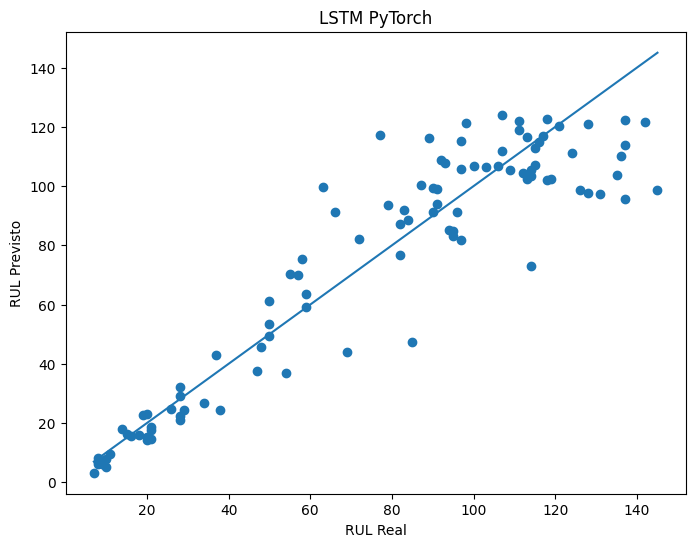

In [105]:
# =========================================================
# 18. REAL VS PREVISTO
# =========================================================
plt.figure(figsize=(8,6))

plt.scatter(
    rul_test['RUL'],
    y_pred
)

plt.plot(
    [
        rul_test['RUL'].min(),
        rul_test['RUL'].max()
    ],
    [
        rul_test['RUL'].min(),
        rul_test['RUL'].max()
    ]
)

plt.xlabel("RUL Real")
plt.ylabel("RUL Previsto")

plt.title("LSTM PyTorch")

plt.show()

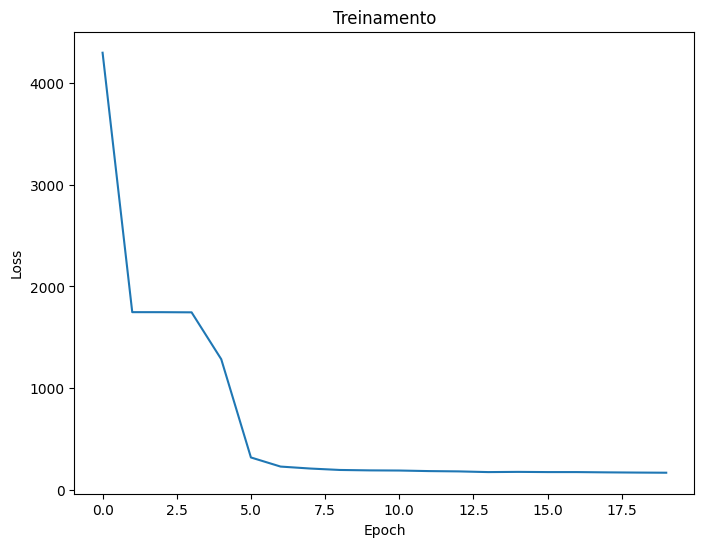

In [106]:
# =========================================================
# 19. LOSS
# =========================================================
plt.figure(figsize=(8,6))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Treinamento")

plt.show()